## Setting up and Training NN 

### *–––– Set up ––––*

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
# import tensorflow as tf
# from tensorflow.keras import layers, models
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import warnings
np.random.seed(42)
warnings.filterwarnings("ignore")

### *–––– reweighing the pT distribution ––––*

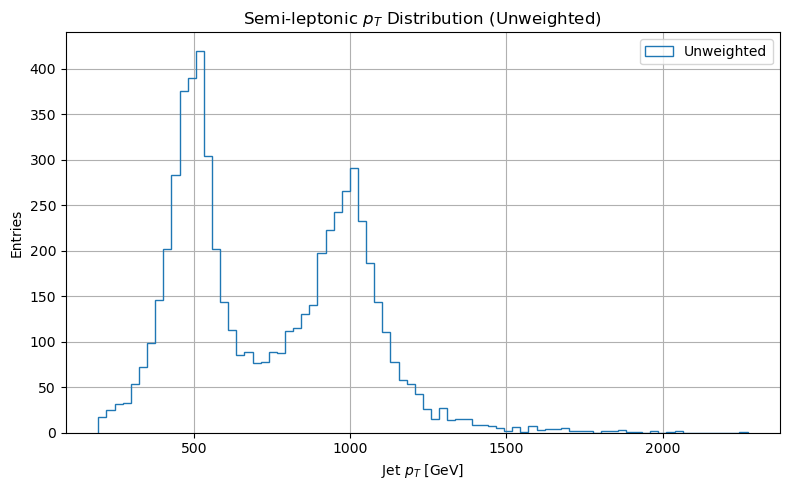

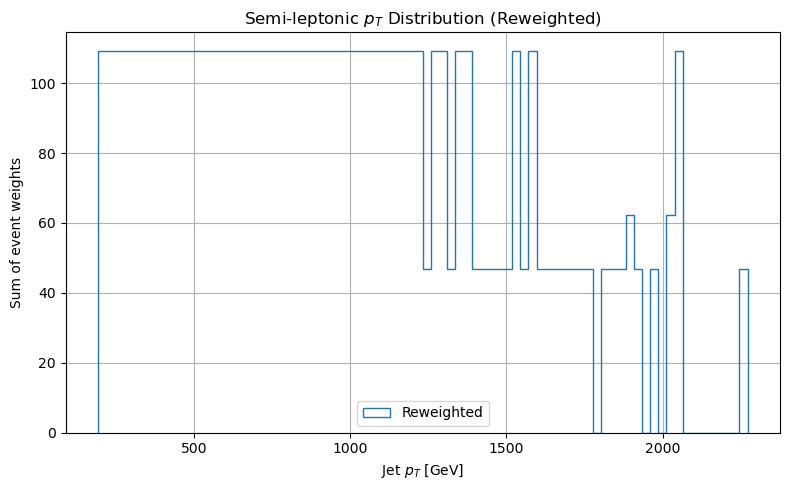

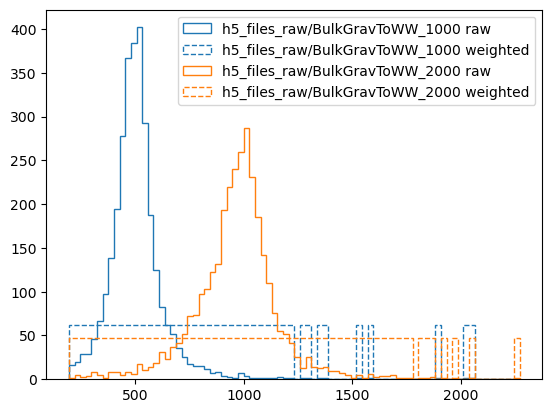

h5_files_raw/BulkGravToWW_1000: sum(weights) = 3051.0  (should ≃ 3051)
h5_files_raw/BulkGravToWW_2000: sum(weights) = 3182.0  (should ≃ 3182)


In [13]:
# ——— 1) CONFIGURATION ———

# List semi‑lep feature files & their mass labels:
mass_points = ["h5_files_raw/BulkGravToWW_1000", "h5_files_raw/BulkGravToWW_2000"]
semi_files  = [f"{m}_semi_features.h5"   for m in mass_points]
# Number of pT bins
n_bins = 80
bins = np.linspace(300, 1500, n_bins+1)

# ——— 2) LOAD & CONCAT ———

df_list = []
for mass, fn in zip(mass_points, semi_files):
    df = pd.read_hdf(fn, key="df")
    df["mass"] = mass
    df_list.append(df)
df_all = pd.concat(df_list, ignore_index=True)

# ——— 3) DEFINE COMMON pT BINS ———

pt_min, pt_max = df_all["pt"].min(), df_all["pt"].max()
bins = np.linspace(pt_min, pt_max, n_bins + 1)

df_all["pt_bin"] = pd.cut(df_all["pt"],bins=bins,labels=False,include_lowest=True)

# ——— 5) COMPUTE & ASSIGN WEIGHTS ———

df_all["weight"] = 0.0

for mass in mass_points:
    mask = df_all["mass"] == mass
    pts = df_all.loc[mask, "pt"]
    # raw histogram counts per bin
    counts, _ = np.histogram(pts, bins=bins)
    # avoid division by zero
    counts = np.where(counts == 0, 1, counts)
    # map each event to 1/counts[its_bin]
    w = 1.0 / counts[df_all.loc[mask, "pt_bin"].values]
    # normalize so sum(weights) == original N_events
    w *= len(w) / w.sum()
    df_all.loc[mask, "weight"] = w

# ––– 6) Plot UNWEIGHTED distribution and WEIGHTED distribution

plt.figure(figsize=(8,5))
plt.hist(df_all["pt"], bins=bins, histtype="step", label="Unweighted")
plt.xlabel("Jet $p_T$ [GeV]")
plt.ylabel("Entries")
plt.title("Semi‑leptonic $p_T$ Distribution (Unweighted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_all["pt"], bins=bins, weights=df_all["weight"], histtype="step", label="Reweighted")
plt.xlabel("Jet $p_T$ [GeV]")
plt.ylabel("Sum of event weights")
plt.title("Semi‑leptonic $p_T$ Distribution (Reweighted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

for mass, color in zip(mass_points, ["C0","C1"]):
    mask = df_all.mass==mass
    plt.hist(df_all.pt[mask], bins=bins, histtype="step", label=f"{mass} raw", color=color)
    plt.hist(df_all.pt[mask], bins=bins, weights=df_all.weight[mask],
             histtype="step", linestyle="--", label=f"{mass} weighted", color=color)
plt.legend(); plt.show()

for mass in mass_points:
    total_w = df_all.loc[df_all.mass==mass, "weight"].sum()
    N       = len(df_all.loc[df_all.mass==mass])
    print(f"{mass}: sum(weights) = {total_w:.1f}  (should ≃ {N})")

In [14]:
# ——— 7) CLEAN UP & SAVE ———
df_all.drop(columns="pt_bin", inplace=True)
outname = "h5_files/semi_combined_reweighted.h5"
df_all.to_hdf(outname, key="df", mode="w")
print(f"Saved {outname} with {len(df_all)} events (weights added).")

Saved h5_files/semi_combined_reweighted.h5 with 6233 events (weights added).


### *–––#1: Data Loading and Labelling––––*

In [15]:
# ——— 1) LOAD THE TWO H5 FILES ———

# Bulk (mostly longitudinal W)  → label y = 1
df_bulk = pd.read_hdf("h5_files/bulk_semi_combined_reweighted.h5", key="df")
df_bulk["y"] = 1

# RS (mostly transverse W)      → label y = 0
df_rs   = pd.read_hdf("h5_files/rs_semi_combined_reweighted.h5",   key="df")
df_rs["y"]   = 0

# ——— 2) CONCATENATE INTO A SINGLE DATAFRAME ———
df = pd.concat([df_bulk, df_rs], ignore_index=True)

# ——— drop the old label column to avoid confusion ———
if "label" in df.columns:
    df = df.drop(columns="label")

# ——— 3) BASIC SANITY CHECKS ———
print("Total events:", len(df))
print("Label balance:\n", df["y"].value_counts(), "\n")
print("Columns available:", list(df.columns))

# Optional: peek at the first few rows
display(df.head())

Total events: 11361
Label balance:
 y
1    6233
0    5128
Name: count, dtype: int64 

Columns available: ['pt', 'eta', 'msoft', 'cos', 'channel', 'mass', 'weight', 'y']


,pt,eta,msoft,cos,channel,mass,weight,y
0,490.75,-0.167938,84.1875,-0.544380,semi,h5_files/BulkGravToWW_1000,0.162149,1
1,568.50,-0.891235,84.6250,0.316163,semi,h5_files/BulkGravToWW_1000,0.331198,1
2,556.00,0.910034,90.4375,-0.210119,semi,h5_files/BulkGravToWW_1000,0.212510,1
3,524.00,0.588135,83.7500,0.241387,semi,h5_files/BulkGravToWW_1000,0.154889,1
4,375.25,1.787842,71.5000,-0.647780,semi,h5_files/BulkGravToWW_1000,0.641910,1


### *––––#2: Train/validation/test split––––*

In [16]:
from sklearn.model_selection import train_test_split

# ——— 2) TRAIN / VALIDATION / TEST SPLIT ———

# First, drop any rows with missing target (just in case)
df = df.dropna(subset=["y"])

# Split off the test set (20% of the data)
trainval_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["y"],
    random_state=42,
)

# Now split trainval into train (60%) and val (20%)
# Since trainval is 80% total, val_size=0.25 yields 0.25 * 0.80 = 0.20 overall
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.25,
    stratify=trainval_df["y"],
    random_state=42,
)

# Quick sanity checks
print("Total:       ", len(df))
print("Training:    ", len(train_df), "(≈60%)")
print("Validation:  ", len(val_df),   "(≈20%)")
print("Test:        ", len(test_df),  "(≈20%)")

print("\nLabel distribution in each split:")
for name, subset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name}:")
    print(subset["y"].value_counts(normalize=True).rename_axis("y").reset_index(name="fraction"))

Total:        11361
Training:     6816 (≈60%)
Validation:   2272 (≈20%)
Test:         2273 (≈20%)

Label distribution in each split:
  Train:
   y  fraction
0  1  0.548709
1  0  0.451291
  Val:
   y  fraction
0  1  0.548415
1  0  0.451585
  Test:
   y  fraction
0  1  0.548614
1  0  0.451386


### *–––––#3: Feature preprocessing––––*

In [17]:
# 3) Preprocessing pipeline
features = ["pt", "eta", "msoft", "cos"]
preprocessor = ColumnTransformer([
    ("scale", StandardScaler(), features)
], remainder="drop")

# Fit & transform
preprocessor.fit(train_df[features])
X_train = preprocessor.transform(train_df[features])
X_val   = preprocessor.transform(val_df[features])
X_test  = preprocessor.transform(test_df[features])

# Convert back to DataFrame for inspection
train_processed = pd.DataFrame(X_train, columns=features, index=train_df.index)
val_processed   = pd.DataFrame(X_val,   columns=features, index=val_df.index)
test_processed  = pd.DataFrame(X_test,  columns=features, index=test_df.index)

# Labels and weights
y_train = train_df["y"].values
y_val   = val_df["y"].values
y_test  = test_df["y"].values

w_train = train_df["weight"].values
w_val   = val_df["weight"].values
w_test  = test_df["weight"].values

# Quick check
print("Processed training features head:")
print(train_processed.head())
print("\nLabel distribution in train/val/test:")
print("Train:", pd.Series(y_train).value_counts())
print("Val:  ", pd.Series(y_val).value_counts())
print("Test: ", pd.Series(y_test).value_counts())

Processed training features head:
             pt       eta     msoft       cos
8930  -0.878603 -2.163746  0.260036  0.854463
8335  -1.016583  0.134551  0.203580  0.876605
10755  0.515438 -1.012353  0.140351 -0.981594
9628   1.159938  0.598283 -1.067930  0.317304
9923   1.601473  0.846417 -1.001877 -0.466125

Label distribution in train/val/test:
Train: 1    3740
0    3076
Name: count, dtype: int64
Val:   1    1246
0    1026
Name: count, dtype: int64
Test:  1    1247
0    1026
Name: count, dtype: int64


### *––––#4: Model Architecture––––*

In [93]:
# ── 1) Instantiate the model ──────────────────────────────────────────────────
model = HistGradientBoostingClassifier(
    loss="log_loss",       
    learning_rate=0.05,
    max_iter=200,          
    max_depth=10,
    max_leaf_nodes=32,
    min_samples_leaf=25,
    validation_fraction=0.2,
    n_iter_no_change=50,   
    random_state=42,
)

### *––––#5: Training––––*

In [94]:
# ── Fit with sample weights ────────────────────────────────────────────────
model.fit(
    X_train, 
    y_train,
    sample_weight=w_train,
)

# ── 3) Predictions & probabilities ────────────────────────────────────────────
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

### *––––#6: Evaluation & diagnostics––––*

Test Accuracy : 0.580
Precision     : 0.627
Recall        : 0.638
F1 Score      : 0.632


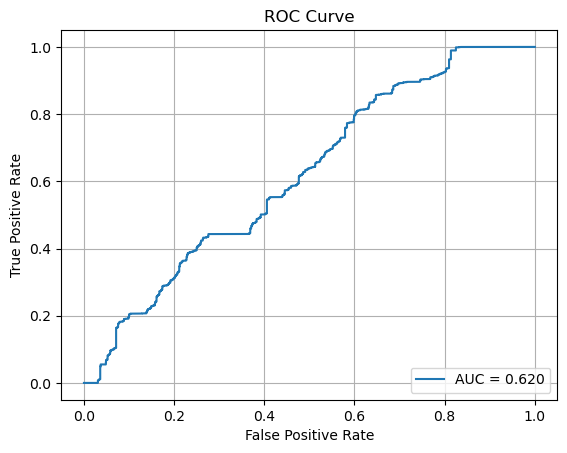

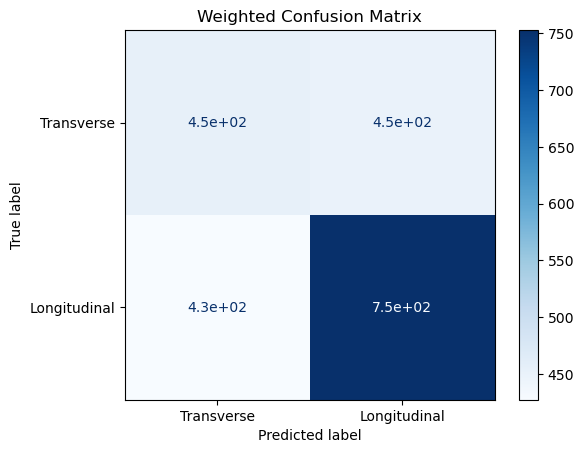

In [95]:
# ── Metrics ─────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred, sample_weight=w_test)
prec = precision_score(y_test, y_pred, sample_weight=w_test)
rec  = recall_score(y_test, y_pred, sample_weight=w_test)
f1   = f1_score(y_test, y_pred, sample_weight=w_test)

print(f"Test Accuracy : {acc:.3f}")
print(f"Precision     : {prec:.3f}")
print(f"Recall        : {rec:.3f}")
print(f"F1 Score      : {f1:.3f}")

# ── 5) ROC & AUC ───────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba, sample_weight=w_test)
roc_auc     = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
# plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# ── 6) Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Transverse","Longitudinal"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Weighted Confusion Matrix")
plt.show()